# Analysis of LLM models for RAGAS evaluations

Here I will look at the following metrics to see which models best handle use of Pubmed Central Abstracts and full text chunks to answer questions of the user. While these metrics are linked in the README.md file for this respository, what's important here is a relative comparison of the metric scores among the 4 models considered:

- granite3.3:2b
- llama3.1:8b
- qwen3:8b
- gpt-oss:20b

Most metrics were done we LLM as a Judge paradigm with OpenAI's GPT4.1. This model was the only one I found that consistently had a big enough context window to support the context load of the RAGAS metrics being evaluated.



In [1]:
# Get reports

from pathlib import Path, PosixPath
import json
from typing import Dict, List

data_dir = Path('.').parent / "reports"

def get_reports(dir: Path) -> List[PosixPath]:
    return [f for f in dir.iterdir() if f.is_file() and f.suffix == ".json"]

def load_reports(file_names: str) -> Dict:
    reports = get_reports(data_dir)
    return {f.name: json.loads(open(f).read()) for f in reports}

reports = load_reports(data_dir)
for key in reports.keys():
    print(key)

ragas_medqa_report_granite3-3-2b_search.json
ragas_medqa_report_llama3-1-8b_search.json
ragas_medqa_report_qwen3-8b_search.json
ragas_medqa_report_qwen3-8b_fulltext.json
ragas_medqa_report_llama3-1-8b_fulltext.json
ragas_medqa_report_gpt-oss-20b_search.json
ragas_medqa_report_granite3-3-2b_fulltext.json
ragas_medqa_report_gpt-oss-20b_fulltext.json


In [2]:
# Sort reports into organized metrics

import pandas as pd

search_qa_data = []
fulltext_qa_data = []

for report, data in reports.items():
    model = data.get('config').get('agent_model')
    mode = data.get('config').get('eval_mode')
    metrics = data.get('config').get('metrics')
    summary = {f"{metric}_mean": data.get('summary').get(f'{metric}_mean') for metric in metrics}
    summary.update({"model": model})
    if mode == "search":
        search_qa_data.append(summary)
    elif mode == 'fulltext':
        fulltext_qa_data.append(summary)
    else:
        continue

search_qa = pd.DataFrame(search_qa_data)
fulltext_qa = pd.DataFrame(fulltext_qa_data)
print("search qa metrics\n")
print(search_qa.head())
print("\nfulltext qa metrics\n")
print(fulltext_qa.head())

search qa metrics

   noise_sensitivity_mean  answer_relevancy_mean  answer_similarity_mean  \
0                0.072115               0.906399                0.694677   
1                0.169516               0.634501                0.498310   
2                0.138889               0.821832                0.614390   
3                0.125356               0.803897                0.569464   

   answer_accuracy_mean  context_precision_mean          model  
0              0.250000                0.277778  granite3.3:2b  
1              0.166667                0.277778    llama3.1:8b  
2              0.333333                0.277778       qwen3:8b  
3              0.250000                0.444444    gpt-oss:20b  

fulltext qa metrics

   answer_relevancy_mean          model
0               0.813065       qwen3:8b
1               0.558749    llama3.1:8b
2               0.786820  granite3.3:2b
3               0.726883    gpt-oss:20b


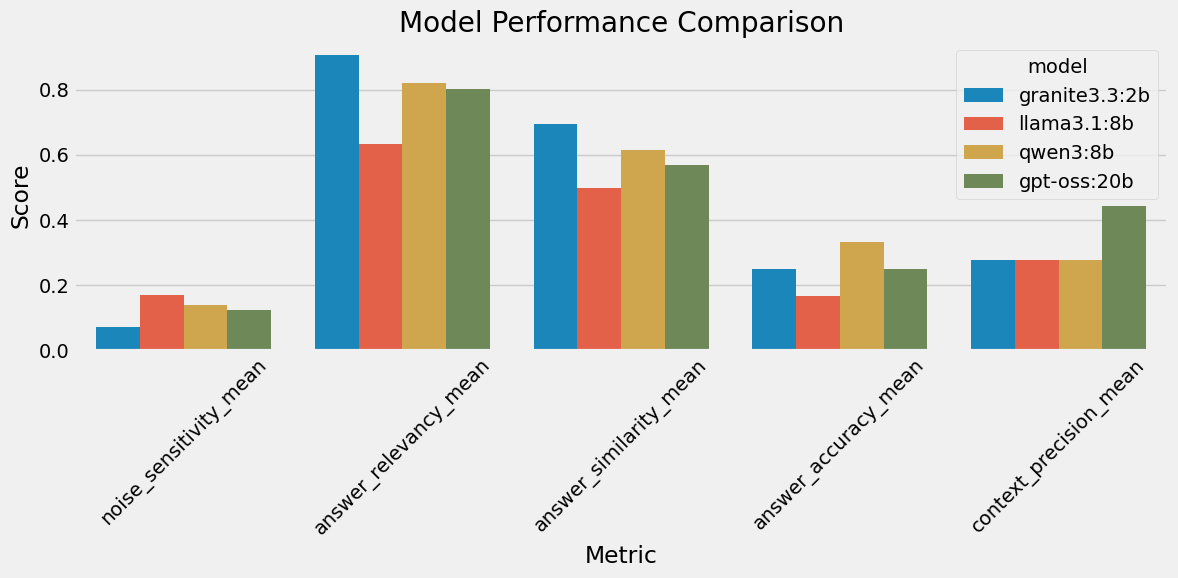

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight') 
model_colors = {
    'granite3.3:2b': '#008fd5', # Classic 538 Blue
    'llama3.1:8b': '#fc4f30',   # Classic 538 Red
    'qwen3:8b': '#e5ae38',      # Classic 538 Gold
    'gpt-oss:20b': '#6d904f'    # Classic 538 Green
}

df_search = search_qa.melt(id_vars='model', var_name='Metric', value_name='Score')


plt.figure(figsize=(12, 6))
sns.barplot(data=df_search, x='Metric', y='Score', hue='model', palette=model_colors)

plt.title('Model Performance Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

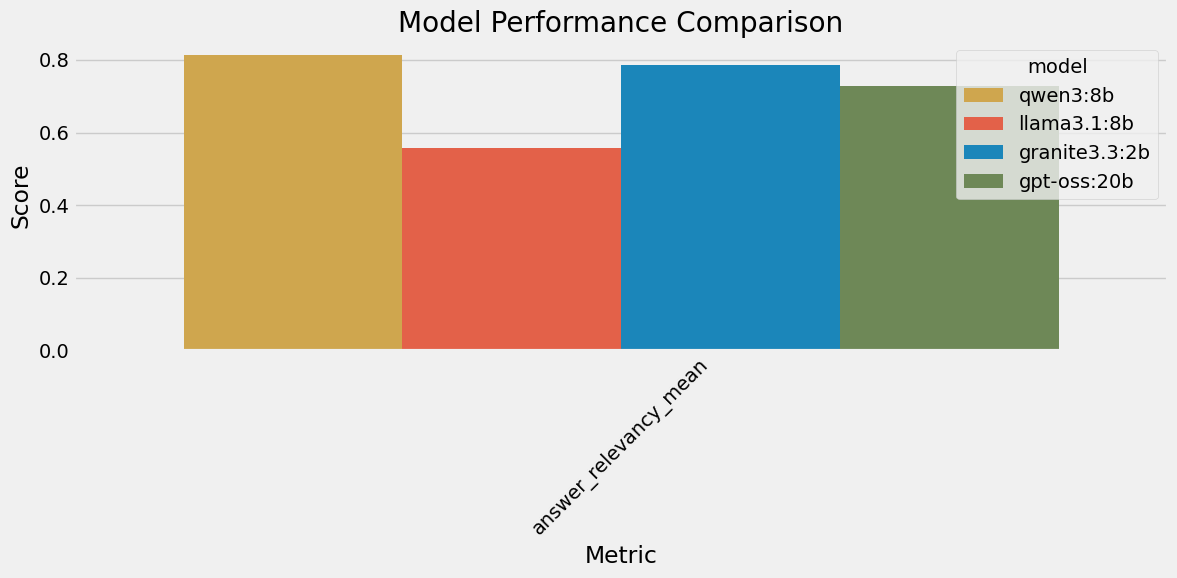

In [10]:
df_fulltext = fulltext_qa.melt(id_vars='model', var_name='Metric', value_name='Score')


plt.figure(figsize=(12, 6))
sns.barplot(data=df_fulltext, x='Metric', y='Score', hue='model', palette=model_colors)

plt.title('Model Performance Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()